In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D


In [4]:
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_data_with_umls_mondo_parents_mondo_clean.csv"
preclin_data = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)
preclin_data = preclin_data.drop_duplicates(subset=["PMID"])
preclin_data.shape

(547365, 19)

In [25]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclin_data = preclin_data.merge(metadata_df_year, on="PMID", how="left")

In [5]:
import re

JUNK_PATTERNS = [
    r'^\s*["\']?\s*#?\s*\d+\s*[,"\']?\s*$',  # " 528', '# 0451', '# 2714', 528, 1,234
]

def _is_junk_token(tok: str) -> bool:
    """Return True if token is meaningless junk like '# 0451', '" 528\'', '()', etc."""
    s = tok.strip().strip('"').strip("'").strip()

    # Empty or one-character junk
    if not s or len(s) < 2:
        return True

    # Pure punctuation / brackets / quotes / plus/minus
    if re.fullmatch(r"^[\(\)\[\]\{\}\'\"\,\.\#\s\-\_\+\=]+$", s):
        return True

    # Numeric garbage possibly prefixed/suffixed by punctuation
    if re.fullmatch(r'^[#\s\'\"\(\)\+\-]*\d+[\'\"\)\s,]*$', s):
        return True

    # Hash-prefixed or leading garbage like '# #', '# 0451'
    if s.startswith("#") and not re.search(r"[A-Za-z]", s):
        return True

    # Junk like empty parentheses or stray symbols
    if s in {"()", "( )", "''", '""', "''", "'"}:
        return True

    return False


def clean_predictions(drugs_list: str) -> str:
    """
    Clean and normalize a pipe-separated list of drug names.
    Removes artifacts (like '# # 45-65-nh2', '" 528'), filters mechanistic terms,
    and maps known synonyms to canonical drug names.
    Keeps valid names like 'mir-1192' or 'antagomir-21' intact.
    """
    if not isinstance(drugs_list, str) or not drugs_list.strip():
        return drugs_list

    drug_names = drugs_list.split("|")
    drug_names_clean = set()

    for drug_name in drug_names:
        dn = drug_name.strip().strip('"').strip("'").strip()

        # Junk or meaningless tokens
        if _is_junk_token(dn):
            continue

        # Skip mechanistic/generic category terms
        if any(word in dn.lower() for word in [
            "antibody", "channel", "receptor", "modulator",
            "blocker", "agonist", "antagonis", "anti-", "inhibitor"
        ]):
            continue

        # Canonical name mappings (case-insensitive)
        ln = dn.lower()
        if ln in ["fty720-c2", "fingolimod-1 phosphate"]:
            dn = "Fingolimod"
        elif ln in [
            "1,25-dihydroxyvitamin d", "1alpha,25-dihydroxyvitamin d",
            "vitamin d", "vitamin d3", "calcitriol", "cholecalciferol"
        ]:
            dn = "vitamin D3"
        elif ln in ["beta interferon", "interferon beta (recombinant)"]:
            dn = "beta 1 Interferon"

        # Valid alphanumeric-hyphen pattern (keep mir-1192, agomir-21, etc.)
        if not re.match(r'^[A-Za-z0-9\-\s\(\)]+$', dn):
            continue

        # Too short or empty
        if not dn or len(dn) < 2:
            continue

        drug_names_clean.add(dn)

    # Return cleaned list or fallback to original
    return "|".join(sorted(drug_names_clean)) if drug_names_clean else drugs_list


In [6]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq


In [26]:
fda_metadata = pd.read_csv("./out/fda_drug_metadata_progress.csv")
fda_metadata = fda_metadata[fda_metadata['approval_year'].notna()]
fda_metadata

,canonical_drug_name,queried_name,approval_year,pharm_class_epc,pharm_class_moa,sponsor_name
0,Dexamethasone,dexamethasone,1962.0,['Corticosteroid [EPC]'],['Corticosteroid Hormone Receptor Agonists [Mo...,HARROW EYE
1,Acetylcysteine,acetylcysteine,1994.0,"['Antidote [EPC]', 'Antidote for Acetaminophen...",['Reduction Activity [MoA]'],HOSPIRA
2,Doxorubicin,doxorubicin,1987.0,NaN,NaN,PFIZER
4,Sirolimus,sirolimus,1999.0,"['mTOR Inhibitor Immunosuppressant [EPC]', 'Ki...","['mTOR Inhibitors [MoA]', 'Protein Kinase Inhi...",PF PRISM CV
6,Cisplatin,cisplatin,1978.0,['Platinum-based Drug [EPC]'],NaN,HQ SPCLT PHARMA
...,...,...,...,...,...,...
43652,β3,3,2014.0,NaN,NaN,GLW
44005,flortaucipir,flortaucipir,2020.0,NaN,NaN,AVID RADIOPHARMS INC
44053,", , 3",3,2014.0,NaN,NaN,GLW
44196,risankizumab,risankizumab,2019.0,['Interleukin-23 Antagonist [EPC]'],['Interleukin-23 Antagonists [MoA]'],ABBVIE INC


In [53]:
preclin_dataset_to_clinical = pd.read_csv("data/preclin_dataset_to_clinical.csv")[['PMID', 'drug_term_umls_norm', 'disease_term_mondo_parent_clean', 'n_unique_trials', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase', 'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year',
       'max_phase_start_year', 'study_classification']]
preclin_dataset_to_clinical = preclin_dataset_to_clinical.merge(metadata_df_year, on="PMID", how="left")
preclin_dataset_to_clinical = preclin_dataset_to_clinical.merge(
    fda_metadata[['canonical_drug_name','approval_year']],
    left_on="drug_term_umls_norm",          # the column in preclin_dataset_to_clinical
    right_on="canonical_drug_name",    # the column in fda_metadata
    how="left"
)

In [54]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'drug_term_umls_norm', 'disease_term_mondo_parent_clean',
       'n_unique_trials', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase',
       'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year', 'max_phase_start_year',
       'study_classification', 'year', 'canonical_drug_name', 'approval_year'],
      dtype='object')

In [55]:
preclin_dataset_to_clinical.head()

,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,canonical_drug_name,approval_year
0,157,Lactate,ischemic disease,6.0,NCT04112862,Early Phase 1,2022.0,NCT04858139,Phase 2,NCT01108601,Phase 1/Phase 2,2008.0,2021.0,failed,1975.0,Lactate,1971.0
1,2617,Ethanol,hypochromic anemia,24.0,NCT03930446,Early Phase 1,2016.0,NCT02495883,Phase 4,NCT00016679,Phase 1,2001.0,2013.0,approved,1976.0,NaN,NaN
2,2891,Phenytoin,epilepsy,29.0,NCT00598923,Early Phase 1,2004.0,NCT00146237,Phase 4,NCT00004403,Not Applicable,2000.0,2003.0,approved,1976.0,Phenytoin,1953.0
3,2891,Pentobarbital,epilepsy,3.0,NCT00123578,Phase 1/Phase 2,2004.0,NCT00622570,Phase 3,NCT00622570,Phase 3,2002.0,2002.0,failed,1976.0,Pentobarbital,1973.0
4,3420,Propranolol,ventricular arrhythmias due to cardiac ryanodi...,71.0,NCT01988883,Early Phase 1,2014.0,NCT00060866,Phase 4,NCT00236561,Phase 3,2001.0,2003.0,approved,1976.0,Propranolol,1983.0


In [72]:
dict_fda_approval = dict(zip(preclin_dataset_to_clinical['drug_term_umls_norm'], preclin_dataset_to_clinical['approval_year']))
dict_earliest_phase = dict(zip(preclin_dataset_to_clinical['drug_term_umls_norm'], preclin_dataset_to_clinical['earliest_trial_start_year']))

In [73]:
preclin_data["drug_term_umls_norm_manual_clean"] = preclin_data['drug_term_umls_norm'].apply(lambda x: clean_predictions(x))
preclin_data.head()

,PMID,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,year,drug_term_umls_norm_manual_clean
0,31733831,asthma,isorhynchophylline,asthma,isorhynchophylline,asthma,MONDO:0004979,isorhynchophylline,C0245133,2020.0,isorhynchophylline
1,31733833,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,antgomir-1192|mir-1192|agomir-1192,myocardial infarction,MONDO:0005068,antgomir-1192|mir-1192|agomir-1192,-1|-1|-1,2020.0,agomir-1192|antgomir-1192|mir-1192
2,31733925,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,g2|hla-g2,systemic lupus erythematosus,MONDO:0007915,g2|HLA-G2 Isoform,-1|C0967254,2020.0,HLA-G2 Isoform|g2
3,31733940,cognitive impairment,minocycline,cognitive impairment,minocycline,cognitive disorder,MONDO:0002039,Minocycline,C0026187,2020.0,Minocycline
4,31734027,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,tadalafil|phosphodiesterase type 5 inhibitor t...,oxaliplatin-induced peripheral neuropathy|cumu...,-1|-1|MONDO:0003620,Tadalafil|Tadalafil,C1176316|C1176316,2019.0,Tadalafil


In [74]:
n_unique, freq = count_unique_from_pipe_column(preclin_dataset_to_clinical, "drug_term_umls_norm")
print(f"Unique count: {n_unique}")

Unique count: 4357


In [75]:
n_unique, freq = count_unique_from_pipe_column(preclin_data, "drug_term_umls_norm")
print(f"Unique count: {n_unique}")

Unique count: 335316


In [76]:
n_unique, freq = count_unique_from_pipe_column(preclin_data, "drug_term_umls_norm_manual_clean")
print(f"Unique count: {n_unique}")

Unique count: 218510


In [77]:
freq

,drug_term_umls_norm_manual_clean,n_articles
23191,Dexamethasone,5865
18687,Acetylcysteine,4463
23520,Doxorubicin,4411
30933,NG-Nitroarginine Methyl Ester,4166
36209,Sirolimus,3839
...,...,...
89020,diarylaminopropylamine derivative,1
89021,diarylbenzopyrimidine,1
89022,diarylbenzopyrimidine analogues,1
89023,diarylcoumarins,1


In [78]:
save_path = f"out/unique_drug_terms_{n_unique}.csv"
freq.to_csv(save_path, index=False)

## Build table

In [79]:
def create_df_for_plotting(df,
                           drug_col="Tested drug(s)",
                           year_col="year",
                           pmid_col="PMID",
                           year_range=(2000, 2024)):
    """
    Returns a wide table: rows=drug names, cols=years in range, values=unique article counts (PMID nunique).
    Assumes pipe-separated drugs in `drug_col`.
    """

    # 1) Keep only years in range
    y0, y1 = year_range
    df = df[pd.to_numeric(df[year_col], errors="coerce").between(y0, y1)].copy()
    missing_years = df[year_col].isna().sum()
    if missing_years:
        print(f"[INFO] Dropped {missing_years} rows with missing or invalid '{year_col}' values.")
        
    # 2) Split drugs by '|' and explode to long
    #    - handle NaN / blanks / "not-reported"
    parts = (df[drug_col]
             .astype(str)
             .str.split(r"\s*\|\s*"))
    df_long = df[[pmid_col, year_col]].copy()
    df_long[drug_col] = parts
    df_long = df_long.explode(drug_col, ignore_index=True)

    # 3) Clean drug strings and drop invalid
    def _clean(x):
        x = (x or "").strip()
        return x
    df_long[drug_col] = df_long[drug_col].map(_clean)
    bad = {"", "nan", "none", "not-reported", "not reported"}
    df_long = df_long[~df_long[drug_col].str.lower().isin(bad)]

    # 4) Count unique PMIDs per drug-year
    counts = (df_long
              .drop_duplicates([pmid_col, drug_col, year_col])
              .groupby([drug_col, year_col])[pmid_col]
              .nunique()
              .rename("count")
              .reset_index())

    # 5) Pivot to wide with full year columns
    all_years = list(range(y0, y1 + 1))
    wide = (counts
            .pivot(index=drug_col, columns=year_col, values="count")
            .reindex(columns=all_years)
            .fillna(0)
            .astype(int))

    # 6) Optional: sort rows by total desc
    wide["Total"] = wide.sum(axis=1)
    wide = wide.sort_values("Total", ascending=False)

    return wide

In [80]:
all_drugs_timeline = create_df_for_plotting(preclin_dataset_to_clinical, drug_col="drug_term_umls_norm", year_col="year", pmid_col="PMID", year_range=(1979, 2024))
all_drugs_timeline.head()

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
drug_term_umls_norm,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,7,6,8,3,5,6,7,12,14,11,...,170,141,163,160,148,176,189,138,151,3308
Acetylcysteine,0,0,1,3,3,6,5,5,5,8,...,142,154,161,164,183,167,175,155,138,3031
Sirolimus,0,0,0,0,0,0,0,0,0,0,...,163,169,196,194,225,216,193,180,176,2770
Doxorubicin,0,1,3,0,3,2,5,4,4,6,...,158,139,177,212,208,174,193,174,144,2754
Metformin,0,0,0,0,0,0,0,0,0,0,...,132,157,184,210,257,278,260,254,228,2598


In [81]:
all_drugs_timeline.shape

(4347, 47)

In [82]:
all_drugs_timeline.to_csv("out/all_drugs_mapped_to_clinical_articles_timeline.csv")

## VIZ

In [94]:
def _size_transform(vals, mode="absolute", scale=40, eps=1e-9):
    v = np.asarray(vals, dtype=float)
    if mode == "absolute":              # current behavior
        sz = v * scale
    elif mode == "sqrt":                 # good for wide ranges
        sz = np.sqrt(v) * scale
    elif mode == "log":                  # very aggressive compression
        sz = np.log1p(v) * scale
    elif mode == "row_percent":          # relative to per-drug max
        denom = v.max() if np.isfinite(v.max()) and v.max() > 0 else 1.0
        sz = (v / (denom + eps)) * scale
    else:
        raise ValueError("size_mode must be one of: absolute|sqrt|log|row_percent")
    return sz


In [102]:
def plot_drug_year_bubbles_from_wide(
    drug_years: dict,
    earliest_phase_years: dict,
    wide_df: pd.DataFrame,             # rows=drug names, cols=years (int/str) and maybe 'Total'
    title: str = "Timeline of studies for drugs",
    output_file: str | None = None,
    drugs_custom_order: list | None = None,
    year_range: tuple[int, int] | None = None,
    scale: int = 20
):
    """
    Plot a bubble timeline using a wide table of unique-PMID counts per drug-year.
    - Includes drugs even if approval year is missing; approval marker drawn only when available.
    """

    # 1) Detect year columns
    year_cols = []
    for c in wide_df.columns:
        try:
            y = int(c)
            year_cols.append(y)
        except (TypeError, ValueError):
            pass
    year_cols = sorted(set(year_cols))
    if not year_cols:
        raise ValueError("No year columns detected in `wide_df` (columns must be years or castable to int).")

    if year_range:
        y0, y1 = year_range
        year_cols = [y for y in year_cols if y0 <= y <= y1]

    # Ensure numeric counts, fill NaNs
    for y in year_cols:
        wide_df.loc[:, y] = (
            pd.to_numeric(wide_df.get(y, 0), errors="coerce")
            .fillna(0)
            .astype(int)
        )
    # 2) Choose drugs to plot (use custom order if given; else all index)
    if drugs_custom_order:
        drugs_in_order = [d for d in drugs_custom_order if d in wide_df.index]
    else:
        drugs_in_order = list(wide_df.index)

    n_drugs = len(drugs_in_order)
    print(f"Plotting {n_drugs} drugs")
    if n_drugs == 0:
        raise ValueError("No drugs to plot (check `wide_df.index` and/or `drugs_custom_order`).")

    # 3) Figure and axes
    fig_height = max(4, 0.75 * n_drugs)
    plt.figure(figsize=(12, fig_height))
    ax = plt.gca()

    # 4) Plot per drug (top-to-bottom)
    for i, drug in enumerate(drugs_in_order):
        y_pos = n_drugs - 1 - i
        row = wide_df.loc[drug, year_cols]

        nonzero = row[row > 0]
        if nonzero.empty:
            continue

        size_mode = "absolute"        # or "log" or "row_percent"
        # compute bubble sizes with chosen transform
        sizes = _size_transform(nonzero.values, mode=size_mode, scale=scale)
    
        ax.scatter(
            nonzero.index.astype(int),
            np.full(len(nonzero), y_pos),
            s=sizes,
            alpha=0.7,
        )

        # Labels on bubbles
        for yr, n in nonzero.items():
            ax.text(int(yr), y_pos, int(n), ha="center", va="center", fontsize=8, zorder=3)

        # Earliest clinical marker ONLY if available and valid
        earliest_phase_year = earliest_phase_years.get(drug, None)
        if earliest_phase_year:
            try:
                ay = int(earliest_phase_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color="palegreen",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

        # Approval marker ONLY if available and valid
        appr_year = drug_years.get(drug, None)
        if appr_year:
            try:
                ay = int(appr_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color="grey",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

    # 5) Axis styling
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_yticks(range(n_drugs))
    ax.set_yticklabels(list(reversed(drugs_in_order)), fontsize=16)
    ax.set_ylim(-1, n_drugs)
    ax.set_xlim(min(year_cols) - 0.5, max(year_cols) + 0.5)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    legend_elements = [
    Line2D([0], [0],
           marker='D', linestyle='None',
           markerfacecolor='palegreen', markeredgecolor='black',
           markersize=8, label='Earliest clinical trial'),
    Line2D([0], [0],
           marker='D', linestyle='None',
           markerfacecolor='grey', markeredgecolor='black',
           markersize=8, label='FDA Approval year'),
    ]

    ax.legend(handles=legend_elements, fontsize=14, loc='upper left', frameon=True)

    plt.xlabel("Publication year", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

    plt.show()

Plotting 10 drugs
Saved plot to: viz/top_10_drug_timeline_preclinical_clinical.png


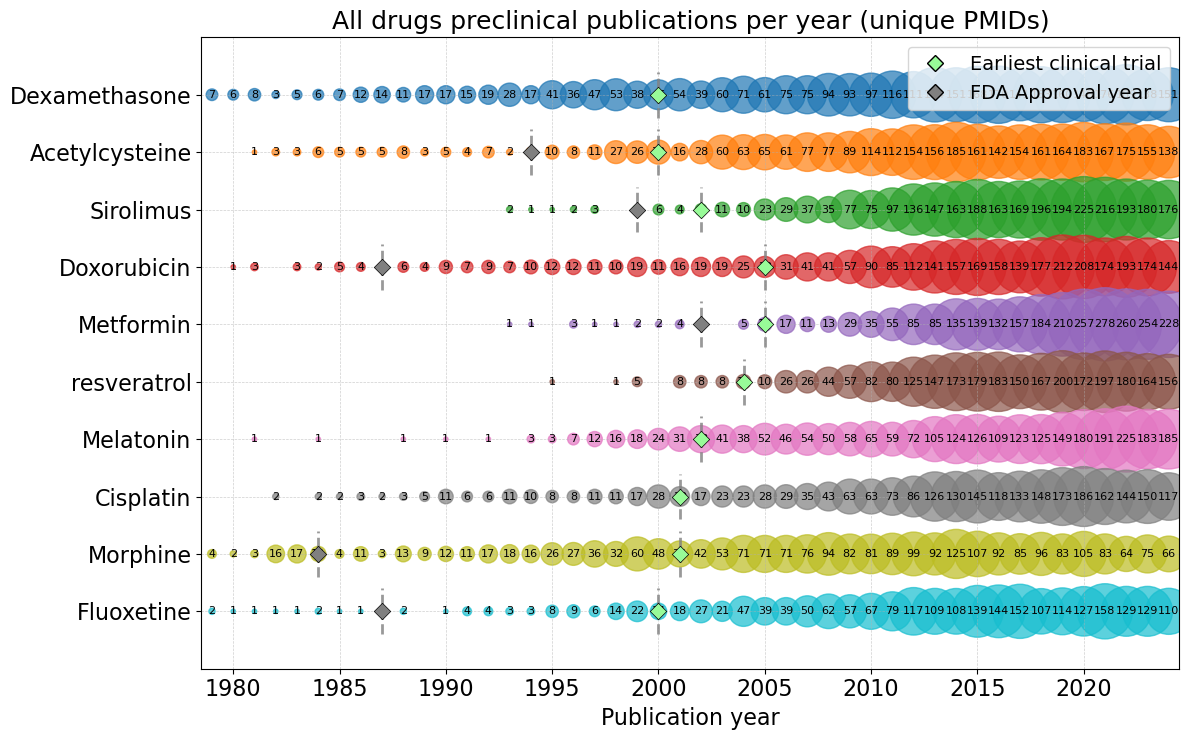

In [108]:
top_n = 10
plot_drug_year_bubbles_from_wide(
    drug_years=dict_fda_approval,
    earliest_phase_years=dict_earliest_phase,
    wide_df=all_drugs_timeline.head(top_n),
    title="All drugs preclinical publications per year (unique PMIDs)",
    output_file=f"viz/top_{top_n}_drug_timeline_preclinical_clinical.png",
    #drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=10
)

In [89]:
preclin_dataset_to_clinical[preclin_dataset_to_clinical['drug_term_umls_norm']=="Naloxone"]

,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,canonical_drug_name,approval_year
19,11999,Naloxone,abstinence,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,1975.0,Naloxone,1986.0
68,30467,Naloxone,respiratory depression,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,1978.0,Naloxone,1986.0
166,86997,Naloxone,quasi-morphine withdrawal syndrome|substance w...,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,1979.0,Naloxone,1986.0
225,119265,Naloxone,audiogenic seizures|epilepsy,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,1979.0,Naloxone,1986.0
307,183962,Naloxone,morphine,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,1976.0,Naloxone,1986.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336869,39684707,Naloxone,obsolete disorder involving pain,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,2024.0,Naloxone,1986.0
338222,37901348,Naloxone,visceral pain,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,2023.0,Naloxone,1986.0
338288,37920212,Naloxone,vincristine induced neuropathic pain|vincristi...,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,2023.0,Naloxone,1986.0
338395,37953754,Naloxone,migraine disorder,26.0,NCT03743805,Early Phase 1,2019.0,NCT00317460,Phase 4,NCT00913484,Phase 2,2000.0,2005.0,approved,2023.0,Naloxone,1986.0


,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,canonical_drug_name,approval_year


# FDA Clean Neuro NMA

In [13]:
fda_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease_drug.csv"
df_map = pd.read_csv(fda_file)[['disease','drug','FDA_approval_year','mondo_term_norm','umls_term_norm']]
df_map.head(10)

,disease,drug,FDA_approval_year,mondo_term_norm,umls_term_norm
0,neuromuscular blockade,sugammadex,2015,neuromuscular blockade,Sugammadex
1,venous thromboembolism,edoxaban,2015,venous thromboembolism,edoxaban
2,atrial fibrillation,edoxaban,2015,atrial fibrillation,edoxaban
3,systemic embolism,edoxaban,2015,pulmonary embolism,edoxaban
4,neuroblastoma,dinutuximab,2015,neuroblastoma,Dinutuximab
5,depression,brexpiprazole,2015,depressive disorder,Brexpiprazole
6,stroke,edoxaban,2015,stroke disorder,edoxaban
7,hypoactive sexual desire disorder,flibanserin,2015,hypoactive sexual desire disorder,flibanserin
8,bipolar disorder,cariprazine,2015,bipolar disorder,Cariprazine
9,schizophrenia,cariprazine,2015,schizophrenia,Cariprazine


#### TODO: regenerate preclin_dataset_to_clinical from Clinical_Translation.ipynb using the new drug parent col

In [26]:
df_trials = pd.read_csv("data/preclin_dataset_to_clinical.csv")[['PMID', 'drug_term_umls_norm', 'disease_term_mondo_parent_clean', 'n_unique_trials', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase', 'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year',
       'max_phase_start_year', 'study_classification']]
df_trials = df_trials.merge(metadata_df_year, on="PMID", how="left")

df_trials.head()

,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year
0,157,Lactate,ischemic disease,6.0,NCT04112862,Early Phase 1,2022.0,NCT04858139,Phase 2,NCT01108601,Phase 1/Phase 2,2008.0,2021.0,failed,1975.0
1,2617,Ethanol,hypochromic anemia,24.0,NCT03930446,Early Phase 1,2016.0,NCT02495883,Phase 4,NCT00016679,Phase 1,2001.0,2013.0,approved,1976.0
2,2891,Phenytoin,epilepsy,29.0,NCT00598923,Early Phase 1,2004.0,NCT00146237,Phase 4,NCT00004403,Not Applicable,2000.0,2003.0,approved,1976.0
3,2891,Pentobarbital,epilepsy,3.0,NCT00123578,Phase 1/Phase 2,2004.0,NCT00622570,Phase 3,NCT00622570,Phase 3,2002.0,2002.0,failed,1976.0
4,3420,Propranolol,ventricular arrhythmias due to cardiac ryanodi...,71.0,NCT01988883,Early Phase 1,2014.0,NCT00060866,Phase 4,NCT00236561,Phase 3,2001.0,2003.0,approved,1976.0


In [123]:
preclin_data[
    preclin_data["merged_umls_label"].str.contains("18F-DOPA", case=False, na=False) &
    preclin_data["merged_mondo_label"].str.contains("parkinson", case=False, na=False)
]#.PMID.nunique()


,PMID,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,linkbert_mapped_conditions,linkbert_mapped_drugs,disease_term_mondo_norm,disease_mondo_termid,drug_term_umls_norm,drug_umls_termid,nearest_dataset_parent_mondo,nearest_dataset_parent_label,merged_mondo_termid,merged_mondo_label,disease_term_mondo_parent_clean,disease_termid_mondo_parent_clean,nearest_dataset_parent_umls,nearest_dataset_parent_umls_label,merged_umls_termid,merged_umls_label,year
546024,1906094,parkinson disease,18f-dopa|l-phenylalanine,parkinson disease,18f-dopa|phenylalanine,Parkinson disease,MONDO:0005180,18f-dopa|Phenylalanine,-1|C0031453,MONDO:0003996,basal ganglia disorder,MONDO:0005180|MONDO:0003996,Parkinson disease|basal ganglia disorder,Parkinson disease|basal ganglia disorder,MONDO:0005180|MONDO:0003996,-1,-1,-1|C0031453,18f-dopa|Phenylalanine,1991.0


In [110]:
synonyms = [
    "18F-DOPA",
    "6-Fluoro-(18F)-L-3,4-Dihydroxyphenylalanine",
    "Fluorodopa (18F)",
    "Fluorodopa F 18",
    "Fluorodopa F-18",
    "L-3,4-Dihydroxy-6-[18F]Fluorophenylalanine",
    "L-6-(18F)Fluoro-DOPA"
]

results = {}

for term in synonyms:
    mask = preclin_data["merged_umls_label"].str.contains(term, case=False, na=False)
    results[term] = {
        "n_matches": mask.sum(),
        "unique_pmids": preclin_data.loc[mask, "PMID"].nunique(),
    }

results


/sctmp/sdonev/ipykernel_1146662/2995915209.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = preclin_data["merged_umls_label"].str.contains(term, case=False, na=False)


{'18F-DOPA': {'n_matches': 1, 'unique_pmids': 1},
 '6-Fluoro-(18F)-L-3,4-Dihydroxyphenylalanine': {'n_matches': 0,
  'unique_pmids': 0},
 'Fluorodopa (18F)': {'n_matches': 0, 'unique_pmids': 0},
 'Fluorodopa F 18': {'n_matches': 0, 'unique_pmids': 0},
 'Fluorodopa F-18': {'n_matches': 1, 'unique_pmids': 1},
 'L-3,4-Dihydroxy-6-[18F]Fluorophenylalanine': {'n_matches': 0,
  'unique_pmids': 0},
 'L-6-(18F)Fluoro-DOPA': {'n_matches': 0, 'unique_pmids': 0}}

In [44]:
df_trials_exp = (
    df_trials
    .assign(
        disease_term_mondo_parent_clean = df_trials["disease_term_mondo_parent_clean"].str.split("|")
    )
    .explode("disease_term_mondo_parent_clean")
)
df_trials_exp.shape

(720054, 17)

In [54]:
df_trials_exp[
    df_trials_exp["drug_clean"].eq("siponimod") &
    df_trials_exp["disease_clean"].str.contains("multiple sclerosis", na=False)
].head(10)


,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,disease_clean,drug_clean
192684,26856814,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2016.0,multiple sclerosis,siponimod
192684,26856814,siponimod,secondary progressive multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2016.0,secondary progressive multiple sclerosis,siponimod
200894,27566665,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2016.0,multiple sclerosis,siponimod
245173,31290453,siponimod,primary progressive multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2019.0,primary progressive multiple sclerosis,siponimod
245173,31290453,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2019.0,multiple sclerosis,siponimod
252007,31821174,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2020.0,multiple sclerosis,siponimod
260594,32488676,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2020.0,multiple sclerosis,siponimod
273252,33577891,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2021.0,multiple sclerosis,siponimod
273252,33577891,siponimod,secondary progressive multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2021.0,secondary progressive multiple sclerosis,siponimod
273253,33577891,siponimod,multiple sclerosis,2.0,NCT01185821,Phase 2,2010.0,NCT03623243,Phase 3,NCT01185821,Phase 2,2010.0,2019.0,failed,2021.0,multiple sclerosis,siponimod


In [65]:
df_trials_exp[
    df_trials_exp["drug_clean"].eq("siponimod") &
    df_trials_exp["disease_clean"].str.contains("multiple sclerosis", na=False)
].PMID.nunique()

27

In [45]:
df_trials.shape

(339072, 17)

In [111]:
df_map["disease_clean"] = df_map["disease"].str.strip().str.lower()
df_map["drug_clean"]    = df_map["drug"].str.strip().str.lower()

df_trials_exp["disease_clean"] = df_trials_exp["disease_term_mondo_parent_clean"].str.strip().str.lower()
df_trials_exp["drug_clean"]    = df_trials_exp["drug_term_umls_norm"].str.strip().str.lower()

# Keep only the (disease, drug) pairs from df_map
pairs = df_map[["disease_clean", "drug_clean"]].drop_duplicates()

df_trials_exp["fda_mapped_disease"] = None


In [112]:
df_trials_exp["fda_mapped_disease"] = None
df_trials_exp["fda_mapped_drug"] = None

for _, row in pairs.iterrows():
    d = row["disease_clean"]    # FDA disease
    dr = row["drug_clean"]      # FDA drug
    
    mask = (
        df_trials_exp["disease_clean"].str.contains(d, case=False, na=False, regex=False) &
        df_trials_exp["drug_clean"].str.contains(dr, case=False, na=False, regex=False)
    )
    
    df_trials_exp.loc[mask, "fda_mapped_disease"] = d
    df_trials_exp.loc[mask, "fda_mapped_drug"] = dr


In [113]:
df_trials_mapped = df_trials_exp.dropna(subset=["fda_mapped_disease", "fda_mapped_drug"])

df_trials_mapped

,PMID,drug_term_umls_norm,disease_term_mondo_parent_clean,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,disease_clean,drug_clean,fda_mapped_disease,fda_mapped_drug
465,407606,Cannabidiol,childhood absence epilepsy,123.0,NCT04280289,Early Phase 1,2020.0,NCT04133480,Phase 4,NCT01610700,Phase 3,2001.0,2020.0,approved,1977.0,childhood absence epilepsy,cannabidiol,epilepsy,cannabidiol
465,407606,Cannabidiol,epilepsy,123.0,NCT04280289,Early Phase 1,2020.0,NCT04133480,Phase 4,NCT01610700,Phase 3,2001.0,2020.0,approved,1977.0,epilepsy,cannabidiol,epilepsy,cannabidiol
5995,2292245,stiripentol,epilepsy with generalized tonic-clonic seizures,2.0,NCT02607891,Phase 2,2016.0,NCT02607891,Phase 2,NCT02607891,Phase 2,2016.0,2016.0,failed,1990.0,epilepsy with generalized tonic-clonic seizures,stiripentol,seizures,stiripentol
7318,2571101,Cannabidiol,epilepsy,123.0,NCT04280289,Early Phase 1,2020.0,NCT04133480,Phase 4,NCT01610700,Phase 3,2001.0,2020.0,approved,1989.0,epilepsy,cannabidiol,epilepsy,cannabidiol
12764,6129147,Cannabidiol,epilepsy,123.0,NCT04280289,Early Phase 1,2020.0,NCT04133480,Phase 4,NCT01610700,Phase 3,2001.0,2020.0,approved,1982.0,epilepsy,cannabidiol,epilepsy,cannabidiol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335341,39523812,givinostat,Duchenne muscular dystrophy,2.0,NCT03373968,Phase 2/Phase 3,2017.0,NCT02851797,Phase 3,NCT02851797,Phase 3,2017.0,2017.0,failed,2025.0,duchenne muscular dystrophy,givinostat,duchenne muscular dystrophy,givinostat
335529,39542230,setmelanotide,obesity-hypoventilation syndrome,3.0,NCT02311673,Phase 2,2015.0,NCT05194124,Phase 3,NCT02311673,Phase 2,2015.0,2021.0,failed,2025.0,obesity-hypoventilation syndrome,setmelanotide,obesity,setmelanotide
336207,39611176,Cannabidiol,epilepsy,123.0,NCT04280289,Early Phase 1,2020.0,NCT04133480,Phase 4,NCT01610700,Phase 3,2001.0,2020.0,approved,2024.0,epilepsy,cannabidiol,epilepsy,cannabidiol
336576,39651055,edoxaban,stroke disorder,6.0,NCT05540587,Phase 2,2022.0,NCT03950076,Phase 4,NCT00781391,Phase 3,2008.0,2019.0,approved,2024.0,stroke disorder,edoxaban,stroke,edoxaban


In [114]:
df_trials_filtered = df_trials_filtered.rename(columns={"fda_mapped_disease": "disease_clean"})
df_trials_filtered = df_trials_filtered.rename(columns={"fda_mapped_drug": "drug_clean"})

df_trials_filtered = df_trials_mapped.merge(
    df_map,
    left_on=["disease_clean", "drug_clean"],
    right_on=["disease_clean", "drug_clean"],
    how="inner"
)

In [115]:
pair_pmid_counts = (
    df_trials_filtered
    .groupby(["drug_clean", "disease_clean"])["PMID"]
    .nunique()
    .reset_index(name="n_pmids")
    .sort_values("n_pmids", ascending=False)
)
print(len(pair_pmid_counts))
pair_pmid_counts

32


,drug_clean,disease_clean,n_pmids
3,cannabidiol,epilepsy,99
27,siponimod,multiple sclerosis,27
2,brivaracetam,epilepsy,26
5,cariprazine,schizophrenia,22
11,edaravone,amyotrophic lateral sclerosis,20
1,brexpiprazole,schizophrenia,14
10,deflazacort,duchenne muscular dystrophy,12
26,selumetinib,neurofibromatosis type 1,10
23,pitolisant,narcolepsy,10
4,cariprazine,bipolar disorder,10


In [116]:
df_trials_filtered.PMID.nunique()

318

In [74]:
df_trials_filtered["year"] = (
    df_trials_filtered["year"]
    .astype("Int64")   # safe integer
)
pmid_counts = (
    df_trials_filtered
    .groupby(["drug_clean", "disease_clean", "year"])["PMID"]
    .nunique()     # count unique PMIDs per year
    .reset_index(name="n_pmids")
)

In [34]:
pmid_counts

,drug_clean,disease_clean,year,n_pmids
0,amifampridine,lambert-eaton myasthenic syndrome,2012,1
1,amifampridine,lambert-eaton myasthenic syndrome,2015,1
2,amifampridine,lambert-eaton myasthenic syndrome,2023,1
3,brexpiprazole,schizophrenia,2017,1
4,brexpiprazole,schizophrenia,2019,1
...,...,...,...,...
73,siponimod,multiple sclerosis,2024,1
74,sugammadex,neuromuscular blockade,2006,1
75,sugammadex,neuromuscular blockade,2011,1
76,sugammadex,neuromuscular blockade,2019,2


In [117]:
pmid_counts["drug_disease"] = (
    pmid_counts["drug_clean"] + " | " + pmid_counts["disease_clean"]
)

pmid_year_matrix = (
    pmid_counts
    .pivot_table(
        index="drug_disease",   # <-- single index now
        columns="year",
        values="n_pmids",
        fill_value=0
    )
)
#pmid_year_matrix["Total"] = pmid_year_matrix.sum(axis=1)
pmid_year_matrix

year,1977,1980,1982,1989,1998,2001,2003,2006,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
drug_disease,,,,,,,,,,,,,,,,,,,,,
amifampridine | lambert-eaton myasthenic syndrome,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
brexpiprazole | schizophrenia,0,0,0,0,0,0,0,0,0,0,...,0,2,0,2,1,2,1,3,0,0
brivaracetam | epilepsy,0,0,0,0,0,0,0,0,0,1,...,1,2,2,0,1,2,3,3,5,0
cannabidiol | epilepsy,1,1,2,1,0,1,1,0,0,0,...,3,4,6,10,14,10,16,17,6,0
cariprazine | bipolar disorder,0,0,0,0,0,0,0,0,0,0,...,0,2,2,1,0,1,0,1,1,0
cariprazine | schizophrenia,0,0,0,0,0,0,0,0,0,0,...,2,2,4,2,1,1,3,3,0,0
casimersen | duchenne muscular dystrophy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
cenobamate | epilepsy,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,1,1,4,0
daclizumab | multiple sclerosis,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [118]:
dict_fda_approval_years = {
    (row["drug"].strip().lower(), row["disease"].strip().lower()): int(row["FDA_approval_year"])
    for _, row in df_map.iterrows()
}
len(dict_fda_approval_years)

123

In [119]:
dict_earliest_phase_years = (
    df_trials_mapped
    .groupby(["drug_clean", "fda_mapped_disease"])["earliest_trial_start_year"]
    .min()
    .dropna()
    .astype(int)
    .to_dict()
)


In [120]:
valid_keys = set(pmid_year_matrix.index)
dict_fda_approval_years_str = {
    f"{drug} | {disease}": year
    for (drug, disease), year in dict_fda_approval_years.items()
}
dict_earliest_phase_years_str = {
    f"{drug} | {disease}": year
    for (drug, disease), year in dict_earliest_phase_years.items()
}


filtered_drug_years = {
    key: year
    for key, year in dict_fda_approval_years_str.items()
    if key in valid_keys
}

filtered_earliest_phase_years = {
    key: year
    for key, year in dict_earliest_phase_years_str.items()
    if key in valid_keys
}


In [121]:
len(filtered_drug_years), len(filtered_earliest_phase_years)

(32, 32)

Plotting 32 drugs
Saved plot to: viz/top_50_drug_timeline_preclinical_clinical.png


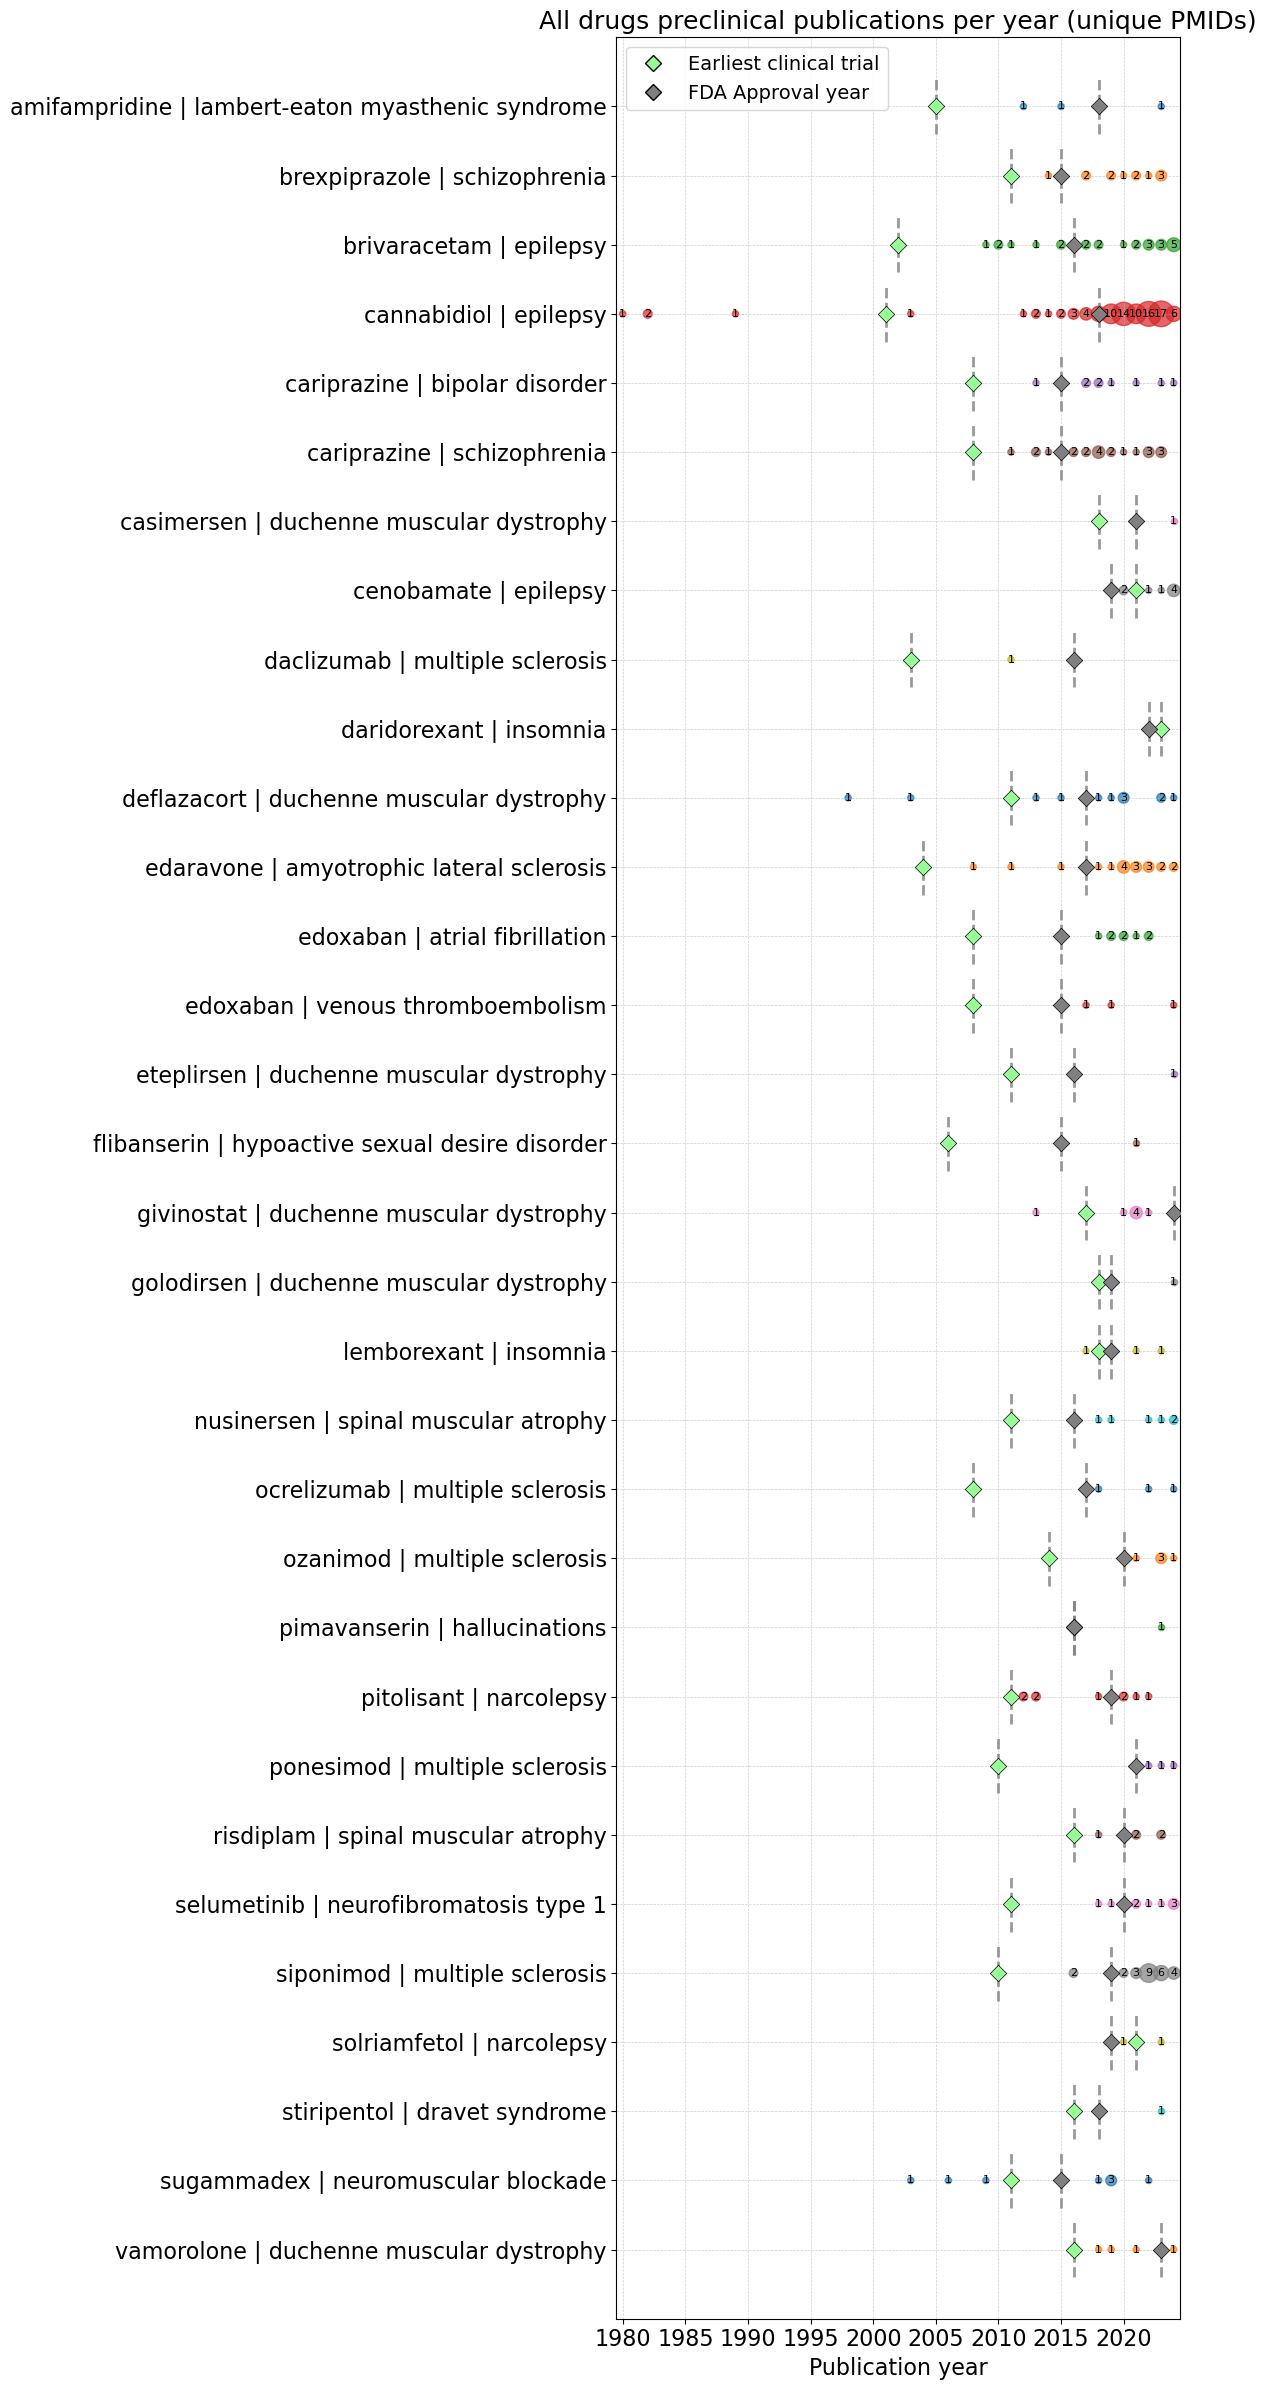

In [122]:
top_n = 50
plot_drug_year_bubbles_from_wide(
    drug_years=filtered_drug_years,
    earliest_phase_years=filtered_earliest_phase_years,
    wide_df=pmid_year_matrix.head(top_n),
    title="All drugs preclinical publications per year (unique PMIDs)",
    output_file=f"viz/top_{top_n}_drug_timeline_preclinical_clinical.png",
    #drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=20
)